# PCBert-Kla Research Workbook

This notebook documents and runs the cleaned PCBert-Kla replication, the proposed token-gated architecture, and the protein language model backbone comparison experiments.



## 1. Notebook Usage

Run this notebook from inside:

`experiment/pcbert_kla_clean/`

In Google Colab, after cloning the repository, use:

```python
%cd /content/Lysine-Lactylation-Sites-Prediction/experiment/pcbert_kla_clean
```

Heavy training cells are controlled by boolean flags such as `RUN_PROTBERT_TOKEN_GATED`. Keep them set to `False` until you intentionally want to run that experiment.

In [1]:
!git clone https://github.com/kaleabnega/Lysine-Lactylation-Sites-Prediction.git
%cd /content/Lysine-Lactylation-Sites-Prediction/experiment/pcbert_kla_clean

Cloning into 'Lysine-Lactylation-Sites-Prediction'...
remote: Enumerating objects: 258, done.
remote: Counting objects: 100% (258/258), done.
remote: Compressing objects: 100% (138/138), done.
remote: Total 258 (delta 98), reused 224 (delta 64), pack-reused 0 (from 0)
Receiving objects: 100% (258/258), 3.35 MiB | 13.77 MiB/s, done.
Resolving deltas: 100% (98/98), done.
/content/Lysine-Lactylation-Sites-Prediction/experiment/pcbert_kla_clean


In [2]:

from pathlib import Path
import json
import os
import shlex
import subprocess
import sys

PROJECT_DIR = Path.cwd()
print("Current directory:", PROJECT_DIR)

expected = PROJECT_DIR / "scripts" / "run_replication.py"
if not expected.exists():
    raise RuntimeError(
        "This notebook should be run from experiment/pcbert_kla_clean. "
        f"Could not find {expected}."
    )

SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project check passed.")

Current directory: /content/Lysine-Lactylation-Sites-Prediction/experiment/pcbert_kla_clean
Project check passed.


## 2. Dependency Setup

On Colab, set `INSTALL_DEPENDENCIES = True` once per fresh runtime. If dependencies are already installed, leave it as `False`.

In [3]:
INSTALL_DEPENDENCIES = True

if INSTALL_DEPENDENCIES:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-r",
        "requirements.txt",
    ])
else:
    print("Skipping dependency installation. Set INSTALL_DEPENDENCIES = True if needed.")

## 3. Helper Functions for Reproducible Commands

The notebook uses the same command-line runner used in the project README. Training cells can either print the command without running it, or execute the command, capture its terminal output, parse the final JSON metrics, and add those metrics to a generated results table.


In [4]:
try:
    import pandas as pd
except ModuleNotFoundError:
    pd = None
    print("pandas is not installed. Set INSTALL_DEPENDENCIES = True and rerun the dependency cell.")

NOTEBOOK_METRICS_DIR = PROJECT_DIR / "outputs" / "notebook_metrics"
NOTEBOOK_METRICS_DIR.mkdir(parents=True, exist_ok=True)

experiment_records = []
metric_cols = ["ACC", "AUC", "AUPRC", "F1", "MCC", "Pre", "Rec", "SP"]


def runner_args(*args: str) -> list[str]:
    return ["python", "scripts/run_replication.py", *args]


def command_text(command: list[str]) -> str:
    return " ".join(shlex.quote(part) for part in command)


def run_command(command: list[str], run: bool = True) -> None:
    print("$", command_text(command))
    if run:
        subprocess.run(command, check=True)


def extract_json_after_marker(output: str, marker: str) -> dict:
    marker_index = output.rfind(marker)
    if marker_index == -1:
        raise ValueError(f"Could not find marker in command output: {marker!r}")

    json_start = output.find("{", marker_index)
    if json_start == -1:
        raise ValueError(f"Could not find JSON object after marker: {marker!r}")

    decoder = json.JSONDecoder()
    parsed, _ = decoder.raw_decode(output[json_start:])
    return parsed


def safe_result_name(label: str) -> str:
    safe = "".join(ch.lower() if ch.isalnum() else "_" for ch in label).strip("_")
    while "__" in safe:
        safe = safe.replace("__", "_")
    return safe or "experiment"


def run_experiment(
    label: str,
    setting: str,
    command: list[str],
    run: bool,
    marker: str = "Independent test:",
) -> dict | None:
    print("$", command_text(command))
    if not run:
        print("Skipped. Set the corresponding RUN_* flag to True to execute this experiment.")
        return None

    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    output_lines = []
    assert process.stdout is not None
    for line in process.stdout:
        print(line, end="")
        output_lines.append(line)
    return_code = process.wait()
    output = "".join(output_lines)
    if return_code != 0:
        raise subprocess.CalledProcessError(return_code, command, output=output)

    metrics = extract_json_after_marker(output, marker)
    record = {
        "Model": label,
        "Setting": setting,
        "Result marker": marker.rstrip(":"),
        **metrics,
        "Command": command_text(command),
    }
    experiment_records.append(record)

    output_path = NOTEBOOK_METRICS_DIR / f"{safe_result_name(label)}.json"
    output_path.write_text(json.dumps(record, indent=2, sort_keys=True))
    print(f"Saved parsed metrics to {output_path.relative_to(PROJECT_DIR)}")
    return record


def require_pandas():
    if pd is None:
        raise ModuleNotFoundError(
            "pandas is required for result tables. "
            "Set INSTALL_DEPENDENCIES = True and rerun the dependency cell."
        )


def load_saved_notebook_metrics():
    require_pandas()
    records = []
    for path in sorted(NOTEBOOK_METRICS_DIR.glob("*.json")):
        records.append(json.loads(path.read_text()))
    return pd.DataFrame(records)


## 4. Dataset Audit

This confirms that the original PCBert-Kla train/test files and physicochemical feature files are being used. It also prints the train/test overlap audit. The overlap is part of the original benchmark split; it is not introduced by this work.

In [5]:
run_command(runner_args("--run", "data-check"), run=True)

$ python scripts/run_replication.py --run data-check


In [6]:
!pwd
!ls
!python scripts/run_replication.py --run data-check

/content/Lysine-Lactylation-Sites-Prediction/experiment/pcbert_kla_clean
main.ipynb  outputs  README.md	requirements.txt  scripts  src
{
  "test": {
    "class_counts": {
      "0": 177,
      "1": 177
    },
    "duplicate_sequence_rows": 5,
    "feature_dim": 27,
    "records": 354,
    "unique_sequences": 349
  },
  "train": {
    "class_counts": {
      "0": 1767,
      "1": 1720
    },
    "duplicate_sequence_rows": 1648,
    "feature_dim": 27,
    "records": 3487,
    "unique_sequences": 1839
  },
  "train_test_overlap": {
    "different_label_test_rows": 4,
    "overlap_test_rows": 255,
    "same_label_test_rows": 251,
    "unique_overlap_sequences": 251
  }
}


## 5. Model Architecture Summary

The proposed method is the token-gated architecture. It keeps the same 51-amino-acid lysine-centered windows and 27 physicochemical features as PCBert-Kla, but changes the downstream neural framework.

Main components:

- protein language model token embeddings from ProtBert, ESM-2, ProtT5, or Ankh,
- central-lysine-guided token attention pooling,
- a separate physicochemical feature projection branch,
- gated fusion between sequence and physicochemical representations,
- residual classifier for final Kla probability prediction.

## 6. Experiment Execution Policy

Metric values are not hardcoded in this notebook. Each table below is generated from commands that are executed in the notebook. The commands are disabled by default to avoid accidental long Colab runs; set the relevant `RUN_*` flag to `True`, run the cell, and the notebook will parse the generated terminal output into `experiment_records`.


In [7]:
print("Metric records currently stored in memory:", len(experiment_records))
print("Parsed metric JSON files will be written to:", NOTEBOOK_METRICS_DIR.relative_to(PROJECT_DIR))


Metric records currently stored in memory: 0
Parsed metric JSON files will be written to: outputs/notebook_metrics


## 7. Paper Baseline Reference

For strict reproducibility, this notebook reads the paper-reported PCBert-Kla independent-test metrics from `outputs/paper_reported_metrics.json` instead of hardcoding them inside the notebook cells. The generated difference table compares newly executed notebook results against that reference file.


In [8]:
paper_metrics_path = PROJECT_DIR / "outputs" / "paper_reported_metrics.json"
if paper_metrics_path.exists():
    paper_metrics = json.loads(paper_metrics_path.read_text())
    print("Loaded paper metrics from", paper_metrics_path.relative_to(PROJECT_DIR))
    if pd is not None:
        display(pd.DataFrame([{ "Model": "Paper PCBert-Kla", **paper_metrics }]))
    else:
        print(paper_metrics)
else:
    paper_metrics = None
    print("No paper metrics JSON found. Difference-from-paper table will be skipped until this file exists.")


Loaded paper metrics from outputs/paper_reported_metrics.json


,Model,ACC,AUC,AUPRC,F1,MCC,Pre,Rec,SP,source
0,Paper PCBert-Kla,0.9497,0.9646,0.9523,0.9505,0.8999,0.9364,0.965,0.9345,PCBert-Kla paper reported independent-test met...


## 8. Command Overview

The following cells define and optionally run the baseline, proposed token-gated model, backbone comparison models, and ensemble model. Results are collected only from executed cells.


In [9]:
print("Available result metrics:", ", ".join(metric_cols))


Available result metrics: ACC, AUC, AUPRC, F1, MCC, Pre, Rec, SP


## 9. Baseline Replication Commands

These cells reproduce the original-style baseline. They are heavy training runs, so they are disabled by default.

In [10]:
RUN_BASELINE_INDEPENDENT = False

baseline_independent_cmd = runner_args(
    "--run", "independent",
    "--epochs", "30",
    "--batch-size", "4",
    "--device", "cuda",
)

run_experiment(
    label="Baseline replication",
    setting="Original PCBert-Kla-style architecture, SGD",
    command=baseline_independent_cmd,
    run=RUN_BASELINE_INDEPENDENT,
    marker="Independent test:",
)


$ python scripts/run_replication.py --run independent --epochs 30 --batch-size 4 --device cuda
Skipped. Set the corresponding RUN_* flag to True to execute this experiment.


In [11]:
RUN_BASELINE_CV = False

baseline_cv_cmd = runner_args(
    "--run", "cv",
    "--epochs", "30",
    "--batch-size", "4",
    "--device", "cuda",
)

run_experiment(
    label="Baseline replication CV",
    setting="Original PCBert-Kla-style architecture, 5-fold CV",
    command=baseline_cv_cmd,
    run=RUN_BASELINE_CV,
    marker="CV mean:",
)


$ python scripts/run_replication.py --run cv --epochs 30 --batch-size 4 --device cuda
Skipped. Set the corresponding RUN_* flag to True to execute this experiment.


## 10. Proposed Main Model: ProtBert + Token-Gated + SGD

This is the strongest single-model architecture result obtained so far. It fine-tunes a truncated 4-layer ProtBert encoder together with the token-gated prediction head.

In [12]:
RUN_SAVE_BEST_PROTBERT_MODEL = True

save_best_protbert_cmd = runner_args(
    "--run", "independent",
    "--architecture", "token_gated",
    "--epochs", "30",
    "--batch-size", "4",
    "--device", "cuda",
    "--optimizer", "sgd",
    "--learning-rate", "0.003",
    "--weight-decay", "0.0",
    "--scheduler", "none",
    "--save-models",
    "--output-dir", "outputs/best_protbert_token_gated_sgd",
)

run_experiment(
    label="ProtBert token-gated saved model",
    setting="SGD, 4 encoder layers, fine-tuned, saved checkpoint",
    command=save_best_protbert_cmd,
    run=RUN_SAVE_BEST_PROTBERT_MODEL,
    marker="Independent test:",
)


Streaming output truncated to the last 5000 lines.
                                                        

eval:  97%|█████████▋| 85/88 [00:00<00:00, 100.23it/s]
                                                      
epoch=07 train_loss=0.0166 val_loss=0.0290 ACC=0.9914 MCC=0.9830 AUC=0.9997

train: 100%|█████████▉| 782/785 [00:24<00:00, 30.48it/s]
                                                        

eval:  98%|█████████▊| 86/88 [00:00<00:00, 99.16it/s]
                                                     
epoch=08 train_loss=0.0124 val_loss=0.0631 ACC=0.9857 MCC=0.9718 AUC=0.9989

train: 100%|█████████▉| 782/785 [00:25<00:00, 29.98it/s]
                                                        

eval:  94%|█████████▍| 83/88 [00:00<00:00, 96.18it/s]
                                                     
epoch=09 train_loss=0.0067 val_loss=0.0674 ACC=0.9857 MCC=0.9718 AUC=0.9990

train: 100%|█████████▉| 782/785 [00:25<00:00, 28.79it/s]
                                               

{'Model': 'ProtBert token-gated saved model',
 'Setting': 'SGD, 4 encoder layers, fine-tuned, saved checkpoint',
 'Result marker': 'Independent test',
 'ACC': 0.963276836158192,
 'AUC': 0.9715439369274474,
 'AUPRC': 0.9585340423922376,
 'F1': 0.9635854341736695,
 'MCC': 0.9266867882817742,
 'Pre': 0.9555555555555556,
 'Rec': 0.9717514124293786,
 'SP': 0.9548022598870056,
 'loss': 0.24929992309764937,
 'threshold': 0.5,
 'threshold_source': 'fixed',
 'Command': 'python scripts/run_replication.py --run independent --architecture token_gated --epochs 30 --batch-size 4 --device cuda --optimizer sgd --learning-rate 0.003 --weight-decay 0.0 --scheduler none --save-models --output-dir outputs/best_protbert_token_gated_sgd'}

## 11. Backbone Comparison Experiments

The following commands test whether the token-gated framework transfers across protein language model backbones. Run one at a time on Colab GPU.

In [13]:
backbone_commands = {
    "ESM-2 35M token-gated AdamW": runner_args(
        "--run", "independent",
        "--architecture", "token_gated",
        "--model-name", "facebook/esm2_t12_35M_UR50D",
        "--epochs", "30",
        "--batch-size", "4",
        "--device", "cuda",
        "--optimizer", "adamw",
        "--learning-rate", "2e-5",
        "--weight-decay", "0.01",
        "--scheduler", "linear",
        "--warmup-ratio", "0.1",
    ),
    "ProtT5 token-gated frozen": runner_args(
        "--run", "independent",
        "--architecture", "token_gated",
        "--model-name", "Rostlab/prot_t5_xl_half_uniref50-enc",
        "--encoder-layers", "4",
        "--freeze-encoder",
        "--epochs", "30",
        "--batch-size", "2",
        "--device", "cuda",
        "--optimizer", "adamw",
        "--learning-rate", "1e-4",
        "--weight-decay", "0.01",
        "--scheduler", "linear",
        "--warmup-ratio", "0.1",
    ),
    "Ankh-base token-gated frozen": runner_args(
        "--run", "independent",
        "--architecture", "token_gated",
        "--model-name", "ElnaggarLab/ankh-base",
        "--encoder-layers", "4",
        "--freeze-encoder",
        "--epochs", "30",
        "--batch-size", "2",
        "--device", "cuda",
        "--optimizer", "adamw",
        "--learning-rate", "1e-4",
        "--weight-decay", "0.01",
        "--scheduler", "linear",
        "--warmup-ratio", "0.1",
    ),
}

for name, command in backbone_commands.items():
    print("\n#", name)
    print(" ".join(shlex.quote(part) for part in command))


# ESM-2 35M token-gated AdamW
python scripts/run_replication.py --run independent --architecture token_gated --model-name facebook/esm2_t12_35M_UR50D --epochs 30 --batch-size 4 --device cuda --optimizer adamw --learning-rate 2e-5 --weight-decay 0.01 --scheduler linear --warmup-ratio 0.1

# ProtT5 token-gated frozen
python scripts/run_replication.py --run independent --architecture token_gated --model-name Rostlab/prot_t5_xl_half_uniref50-enc --encoder-layers 4 --freeze-encoder --epochs 30 --batch-size 2 --device cuda --optimizer adamw --learning-rate 1e-4 --weight-decay 0.01 --scheduler linear --warmup-ratio 0.1

# Ankh-base token-gated frozen
python scripts/run_replication.py --run independent --architecture token_gated --model-name ElnaggarLab/ankh-base --encoder-layers 4 --freeze-encoder --epochs 30 --batch-size 2 --device cuda --optimizer adamw --learning-rate 1e-4 --weight-decay 0.01 --scheduler linear --warmup-ratio 0.1


In [14]:
RUN_BACKBONE_NAME = "Ankh-base token-gated frozen"
# Example:
# RUN_BACKBONE_NAME = "Ankh-base token-gated frozen"

if RUN_BACKBONE_NAME is not None:
    run_experiment(
        label=RUN_BACKBONE_NAME,
        setting="Token-gated backbone comparison",
        command=backbone_commands[RUN_BACKBONE_NAME],
        run=True,
        marker="Independent test:",
    )
else:
    print("No backbone command selected. Set RUN_BACKBONE_NAME to one of:")
    for key in backbone_commands:
        print("-", key)


Streaming output truncated to the last 5000 lines.
train: 100%|█████████▉| 1568/1569 [00:21<00:00, 68.80it/s]
                                                          

eval:  98%|█████████▊| 172/175 [00:01<00:00, 122.73it/s]
                                                        
epoch=08 train_loss=0.0756 val_loss=0.0716 ACC=0.9857 MCC=0.9718 AUC=0.9915

train: 100%|██████████| 1569/1569 [00:21<00:00, 58.35it/s]
                                                          

eval:  98%|█████████▊| 171/175 [00:01<00:00, 86.55it/s]
                                                       
epoch=09 train_loss=0.0463 val_loss=0.0994 ACC=0.9685 MCC=0.9374 AUC=0.9934

train: 100%|██████████| 1569/1569 [00:21<00:00, 79.09it/s]
                                                          

eval:  94%|█████████▎| 164/175 [00:01<00:00, 119.74it/s]
                                                        
epoch=10 train_loss=0.0623 val_loss=0.0907 ACC=0.9685 MCC=0.9389 AUC=0.9945

train: 100%|█████████

In [15]:
RUN_BACKBONE_NAME = "ESM-2 35M token-gated AdamW"


if RUN_BACKBONE_NAME is not None:
    run_experiment(
        label=RUN_BACKBONE_NAME,
        setting="Token-gated backbone comparison",
        command=backbone_commands[RUN_BACKBONE_NAME],
        run=True,
        marker="Independent test:",
    )
else:
    print("No backbone command selected. Set RUN_BACKBONE_NAME to one of:")
    for key in backbone_commands:
        print("-", key)

Streaming output truncated to the last 5000 lines.
train: 100%|█████████▉| 784/785 [00:20<00:00, 40.21it/s]
                                                        

eval:  99%|█████████▉| 87/88 [00:00<00:00, 91.26it/s]
                                                     
epoch=03 train_loss=0.3567 val_loss=0.2826 ACC=0.9054 MCC=0.8121 AUC=0.9360

train: 100%|█████████▉| 782/785 [00:20<00:00, 41.34it/s]
                                                        

eval:  91%|█████████ | 80/88 [00:00<00:00, 126.08it/s]
                                                      
epoch=04 train_loss=0.1908 val_loss=0.1788 ACC=0.9513 MCC=0.9060 AUC=0.9713

train: 100%|█████████▉| 782/785 [00:20<00:00, 41.43it/s]
                                                        

eval:  91%|█████████ | 80/88 [00:00<00:00, 124.37it/s]
                                                      
epoch=05 train_loss=0.1037 val_loss=0.1881 ACC=0.9456 MCC=0.8937 AUC=0.9845

train: 100%|█████████▉| 783/785 [00:19<00:00,

In [16]:
RUN_BACKBONE_NAME = "ProtT5 token-gated frozen"

if RUN_BACKBONE_NAME is not None:
    run_experiment(
        label=RUN_BACKBONE_NAME,
        setting="Token-gated backbone comparison",
        command=backbone_commands[RUN_BACKBONE_NAME],
        run=True,
        marker="Independent test:",
    )
else:
    print("No backbone command selected. Set RUN_BACKBONE_NAME to one of:")
    for key in backbone_commands:
        print("-", key)

Streaming output truncated to the last 5000 lines.
train: 100%|█████████▉| 1566/1569 [00:24<00:00, 66.67it/s]
                                                          

eval:  98%|█████████▊| 172/175 [00:02<00:00, 77.78it/s]
                                                       
epoch=11 train_loss=0.0531 val_loss=0.0625 ACC=0.9828 MCC=0.9662 AUC=0.9933

train: 100%|██████████| 1569/1569 [00:24<00:00, 66.52it/s]
                                                          

eval:  97%|█████████▋| 169/175 [00:02<00:00, 77.43it/s]
                                                       
epoch=12 train_loss=0.0528 val_loss=0.0951 ACC=0.9742 MCC=0.9497 AUC=0.9925

train: 100%|█████████▉| 1567/1569 [00:24<00:00, 52.96it/s]
                                                          

eval:  99%|█████████▉| 173/175 [00:02<00:00, 85.46it/s]
                                                       
epoch=13 train_loss=0.0481 val_loss=0.1481 ACC=0.9685 MCC=0.9389 AUC=0.9883

train: 100%|█████████▉| 1

In [17]:
%cd /content/Lysine-Lactylation-Sites-Prediction
!git pull
%cd /content/Lysine-Lactylation-Sites-Prediction/experiment/pcbert_kla_clean

/content/Lysine-Lactylation-Sites-Prediction
Already up to date.
/content/Lysine-Lactylation-Sites-Prediction/experiment/pcbert_kla_clean


## 12. ProtBert Token-Gated Ablation Study

These experiments keep the main ProtBert token-gated + SGD setup fixed, then remove one component at a time. This is the ablation study requested for scientific justification of the architecture.

Ablation scenarios:

- `no_gated_fusion`: keep the sequence and physicochemical branches, but replace the learnable gate with simple ungated averaging.
- `no_physicochemical`: remove the physicochemical feature branch and classify from the sequence representation only.
- `no_sequence`: remove the sequence branch and classify from the physicochemical representation only.


In [18]:
ablation_commands = {
    "No gated fusion": runner_args(
        "--run", "independent",
        "--architecture", "token_gated",
        "--ablation", "no_gated_fusion",
        "--epochs", "30",
        "--batch-size", "4",
        "--device", "cuda",
        "--optimizer", "sgd",
        "--learning-rate", "0.003",
        "--weight-decay", "0.0",
        "--scheduler", "none",
        "--output-dir", "outputs/ablation_no_gated_fusion",
    ),
    "No physicochemical features": runner_args(
        "--run", "independent",
        "--architecture", "token_gated",
        "--ablation", "no_physicochemical",
        "--epochs", "30",
        "--batch-size", "4",
        "--device", "cuda",
        "--optimizer", "sgd",
        "--learning-rate", "0.003",
        "--weight-decay", "0.0",
        "--scheduler", "none",
        "--output-dir", "outputs/ablation_no_physicochemical",
    ),
    "No sequence data": runner_args(
        "--run", "independent",
        "--architecture", "token_gated",
        "--ablation", "no_sequence",
        "--epochs", "30",
        "--batch-size", "4",
        "--device", "cuda",
        "--optimizer", "sgd",
        "--learning-rate", "0.003",
        "--weight-decay", "0.0",
        "--scheduler", "none",
        "--output-dir", "outputs/ablation_no_sequence",
    ),
}

In [19]:
RUN_ABLATION_NAME = "No gated fusion"
# Example:
# RUN_ABLATION_NAME = "No gated fusion"

if RUN_ABLATION_NAME is not None:
    run_experiment(
        label=f"ProtBert token-gated ablation: {RUN_ABLATION_NAME}",
        setting="ProtBert token-gated + SGD with one component removed",
        command=ablation_commands[RUN_ABLATION_NAME],
        run=True,
        marker="Independent test:",
    )
else:
    print("No ablation selected. Set RUN_ABLATION_NAME to one of:")
    for key in ablation_commands:
        print("-", key)

Streaming output truncated to the last 5000 lines.
train: 100%|█████████▉| 784/785 [00:24<00:00, 31.96it/s]
                                                        

eval:  92%|█████████▏| 81/88 [00:00<00:00, 109.00it/s]
                                                      
epoch=07 train_loss=0.0171 val_loss=0.0829 ACC=0.9857 MCC=0.9718 AUC=0.9968

train: 100%|██████████| 785/785 [00:25<00:00, 32.29it/s]
                                                        

eval:  90%|████████▉ | 79/88 [00:00<00:00, 106.83it/s]
                                                      
epoch=08 train_loss=0.0573 val_loss=0.0950 ACC=0.9742 MCC=0.9497 AUC=0.9933

train: 100%|█████████▉| 783/785 [00:25<00:00, 31.50it/s]
                                                        

eval:  91%|█████████ | 80/88 [00:00<00:00, 109.08it/s]
                                                      
epoch=09 train_loss=0.0189 val_loss=0.0768 ACC=0.9857 MCC=0.9718 AUC=0.9962

train: 100%|█████████▉| 782/785 [00:24<00:0

In [20]:
RUN_ABLATION_NAME = "No physicochemical features"

if RUN_ABLATION_NAME is not None:
    run_experiment(
        label=f"ProtBert token-gated ablation: {RUN_ABLATION_NAME}",
        setting="ProtBert token-gated + SGD with one component removed",
        command=ablation_commands[RUN_ABLATION_NAME],
        run=True,
        marker="Independent test:",
    )
else:
    print("No ablation selected. Set RUN_ABLATION_NAME to one of:")
    for key in ablation_commands:
        print("-", key)

Streaming output truncated to the last 5000 lines.
train: 100%|█████████▉| 784/785 [00:24<00:00, 32.29it/s]
                                                        

eval:  95%|█████████▌| 84/88 [00:00<00:00, 110.67it/s]
                                                      
epoch=07 train_loss=0.5106 val_loss=0.6932 ACC=0.5072 MCC=0.0000 AUC=0.5828

train: 100%|█████████▉| 782/785 [00:24<00:00, 32.48it/s]
                                                        

eval:  95%|█████████▌| 84/88 [00:00<00:00, 111.33it/s]
                                                      
epoch=08 train_loss=0.6972 val_loss=0.6961 ACC=0.4928 MCC=0.0000 AUC=0.6519

train: 100%|█████████▉| 783/785 [00:24<00:00, 32.25it/s]
                                                        

eval:  94%|█████████▍| 83/88 [00:00<00:00, 111.51it/s]
                                                      
epoch=09 train_loss=0.6944 val_loss=0.6929 ACC=0.5072 MCC=0.0000 AUC=0.6574

train: 100%|█████████▉| 784/785 [00:24<00:0

In [21]:
RUN_ABLATION_NAME = "No sequence data"

if RUN_ABLATION_NAME is not None:
    run_experiment(
        label=f"ProtBert token-gated ablation: {RUN_ABLATION_NAME}",
        setting="ProtBert token-gated + SGD with one component removed",
        command=ablation_commands[RUN_ABLATION_NAME],
        run=True,
        marker="Independent test:",
    )
else:
    print("No ablation selected. Set RUN_ABLATION_NAME to one of:")
    for key in ablation_commands:
        print("-", key)

$ python scripts/run_replication.py --run independent --architecture token_gated --ablation no_sequence --epochs 30 --batch-size 4 --device cuda --optimizer sgd --learning-rate 0.003 --weight-decay 0.0 --scheduler none --output-dir outputs/ablation_no_sequence

train:  98%|█████████▊| 772/785 [00:03<00:00, 174.59it/s]
                                                         

eval: 100%|██████████| 88/88 [00:00<00:00, 453.05it/s]
                                                      
epoch=01 train_loss=0.6410 val_loss=0.5974 ACC=0.6934 MCC=0.3894 AUC=0.7418

train:  97%|█████████▋| 760/785 [00:03<00:00, 249.82it/s]
                                                         

eval:  60%|██████    | 53/88 [00:00<00:00, 522.87it/s]
                                                      
epoch=02 train_loss=0.6105 val_loss=0.5832 ACC=0.6991 MCC=0.4116 AUC=0.7721

train: 100%|█████████▉| 784/785 [00:03<00:00, 239.58it/s]
                                                         

eval:  57%|██

## 13. Generated Results Table

This table is built from metrics parsed during this notebook session. If you ran experiments in an earlier session, the cell can also reload parsed JSON files from `outputs/notebook_metrics/`.


In [22]:
if pd is None:
    results_df = None
    print("pandas is required for generated result tables. Set INSTALL_DEPENDENCIES = True and rerun the dependency cell.")
else:
    results_df = pd.DataFrame(experiment_records)

    if results_df.empty:
        results_df = load_saved_notebook_metrics()

    if results_df.empty:
        print("No generated experiment metrics yet. Run one or more experiment cells above, then rerun this cell.")
    else:
        display_cols = ["Model", "Setting", *[col for col in metric_cols if col in results_df.columns], "loss", "threshold", "threshold_source"]
        display_cols = [col for col in display_cols if col in results_df.columns]
        display(results_df[display_cols].sort_values(by=[col for col in ["MCC", "ACC"] if col in results_df.columns], ascending=False))


,Model,Setting,ACC,AUC,AUPRC,F1,MCC,Pre,Rec,SP,loss,threshold,threshold_source
0,ProtBert token-gated saved model,"SGD, 4 encoder layers, fine-tuned, saved check...",0.963277,0.971544,0.958534,0.963585,0.926687,0.955556,0.971751,0.954802,0.249300,0.5,fixed
4,ProtBert token-gated ablation: No gated fusion,ProtBert token-gated + SGD with one component ...,0.963277,0.970922,0.948438,0.963585,0.926687,0.955556,0.971751,0.954802,0.281706,0.5,fixed
1,Ankh-base token-gated frozen,Token-gated backbone comparison,0.960452,0.974560,0.969941,0.960674,0.920963,0.955307,0.966102,0.954802,0.329076,0.5,fixed
2,ESM-2 35M token-gated AdamW,Token-gated backbone comparison,0.960452,0.971991,0.957114,0.960452,0.920904,0.960452,0.960452,0.960452,0.370849,0.5,fixed
5,ProtBert token-gated ablation: No physicochemi...,ProtBert token-gated + SGD with one component ...,0.943503,0.974688,0.962780,0.945055,0.888425,0.919786,0.971751,0.915254,0.327379,0.5,fixed
3,ProtT5 token-gated frozen,Token-gated backbone comparison,0.940678,0.971448,0.970261,0.941828,0.882046,0.923913,0.960452,0.920904,0.564281,0.5,fixed
6,ProtBert token-gated ablation: No sequence data,ProtBert token-gated + SGD with one component ...,0.909605,0.959861,0.950069,0.913978,0.823478,0.871795,0.960452,0.858757,0.294730,0.5,fixed


## 14. Difference from the Paper Baseline

This table is generated only when both notebook-generated results and `outputs/paper_reported_metrics.json` are available.


In [23]:
if results_df is None:
    print("pandas is required for this comparison table.")
elif results_df.empty:
    print("No generated experiment metrics available yet.")
elif paper_metrics is None:
    print("No paper reference metrics loaded. Create outputs/paper_reported_metrics.json to generate this comparison.")
else:
    diff_rows = []
    for _, row in results_df.iterrows():
        diff_row = {"Model": row["Model"], "Setting": row["Setting"]}
        for col in metric_cols:
            if col in row and col in paper_metrics:
                diff_row[col] = row[col] - paper_metrics[col]
        diff_rows.append(diff_row)
    diff_df = pd.DataFrame(diff_rows)
    display(diff_df)


,Model,Setting,ACC,AUC,AUPRC,F1,MCC,Pre,Rec,SP
0,ProtBert token-gated saved model,"SGD, 4 encoder layers, fine-tuned, saved check...",0.013577,0.006944,0.006234,0.013085,0.026787,0.019156,0.006751,0.020302
1,Ankh-base token-gated frozen,Token-gated backbone comparison,0.010752,0.009960,0.017641,0.010174,0.021063,0.018907,0.001102,0.020302
2,ESM-2 35M token-gated AdamW,Token-gated backbone comparison,0.010752,0.007391,0.004814,0.009952,0.021004,0.024052,-0.004548,0.025952
3,ProtT5 token-gated frozen,Token-gated backbone comparison,-0.009022,0.006848,0.017961,-0.008672,-0.017854,-0.012487,-0.004548,-0.013596
4,ProtBert token-gated ablation: No gated fusion,ProtBert token-gated + SGD with one component ...,0.013577,0.006322,-0.003862,0.013085,0.026787,0.019156,0.006751,0.020302
5,ProtBert token-gated ablation: No physicochemi...,ProtBert token-gated + SGD with one component ...,-0.006197,0.010088,0.010480,-0.005445,-0.011475,-0.016614,0.006751,-0.019246
6,ProtBert token-gated ablation: No sequence data,ProtBert token-gated + SGD with one component ...,-0.040095,-0.004739,-0.002231,-0.036522,-0.076422,-0.064605,-0.004548,-0.075743


## 15. Plot the Generated Comparison

This plot is generated from `results_df`, so it updates according to the experiments actually run in the notebook.


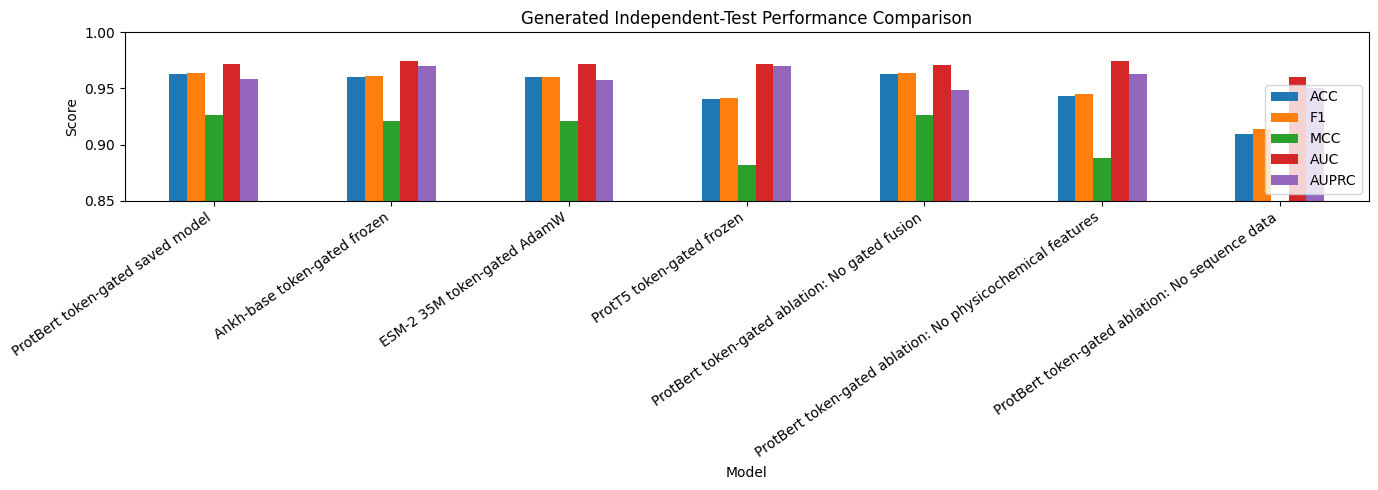

In [24]:
if results_df is None:
    print("pandas is required for this plot.")
elif results_df.empty:
    print("No generated experiment metrics available yet.")
else:
    import matplotlib.pyplot as plt

    plot_cols = [col for col in ["ACC", "F1", "MCC", "AUC", "AUPRC"] if col in results_df.columns]
    plot_df = results_df.set_index("Model")[plot_cols]

    ax = plot_df.plot(kind="bar", figsize=(14, 5), ylim=(0.85, 1.0))
    ax.set_title("Generated Independent-Test Performance Comparison")
    ax.set_ylabel("Score")
    ax.legend(loc="lower right")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()


## 16. Saved Outputs

Independent and ensemble runs save prediction CSV files under `outputs/` by default. Use this cell to inspect generated files after running experiments.


In [25]:
outputs_dir = PROJECT_DIR / "outputs"
if outputs_dir.exists():
    for path in sorted(outputs_dir.rglob("*")):
        if path.is_file():
            print(path.relative_to(PROJECT_DIR))
else:
    print("No outputs directory yet. Run an experiment first.")

outputs/ablation_no_gated_fusion/independent_test_predictions.csv
outputs/ablation_no_physicochemical/independent_test_predictions.csv
outputs/ablation_no_sequence/independent_test_predictions.csv
outputs/best_protbert_token_gated_sgd/feature_scaler_independent.joblib
outputs/best_protbert_token_gated_sgd/independent_test_predictions.csv
outputs/best_protbert_token_gated_sgd/token_gated_independent.pt
outputs/independent_test_predictions.csv
outputs/notebook_metrics/ankh_base_token_gated_frozen.json
outputs/notebook_metrics/esm_2_35m_token_gated_adamw.json
outputs/notebook_metrics/protbert_token_gated_ablation_no_gated_fusion.json
outputs/notebook_metrics/protbert_token_gated_ablation_no_physicochemical_features.json
outputs/notebook_metrics/protbert_token_gated_ablation_no_sequence_data.json
outputs/notebook_metrics/protbert_token_gated_saved_model.json
outputs/notebook_metrics/prott5_token_gated_frozen.json
outputs/paper_reported_metrics.json


## 17. Representation Visualization with t-SNE

This section provides a qualitative visualization of the learned feature space. The first plot uses the fused representation `z` from the trained ProtBert token-gated model, which is the representation passed into the residual classifier after sequence pooling, physicochemical projection, and gated fusion. The second plot uses the original 27 physicochemical features.

The goal is to visually inspect whether lactylated and non-lactylated sites become more separable after the proposed model learns its fused representation. t-SNE is only a visualization tool, so it should be interpreted alongside the quantitative metrics rather than as standalone proof.


### 17.1 Optional: Save the Best ProtBert Token-Gated Model

Run this cell only if the checkpoint does not already exist at `outputs/best_protbert_token_gated_sgd/token_gated_independent.pt`. The model must be saved before the fused representations can be extracted.


In [26]:
RUN_SAVE_BEST_PROTBERT_MODEL = False

save_best_protbert_cmd = runner_args(
    "--run", "independent",
    "--architecture", "token_gated",
    "--epochs", "30",
    "--batch-size", "4",
    "--device", "cuda",
    "--optimizer", "sgd",
    "--learning-rate", "0.003",
    "--weight-decay", "0.0",
    "--scheduler", "none",
    "--save-models",
    "--output-dir", "outputs/best_protbert_token_gated_sgd",
)

run_experiment(
    label="ProtBert token-gated saved model",
    setting="SGD, 4 encoder layers, fine-tuned, saved checkpoint",
    command=save_best_protbert_cmd,
    run=RUN_SAVE_BEST_PROTBERT_MODEL,
    marker="Independent test:",
)


$ python scripts/run_replication.py --run independent --architecture token_gated --epochs 30 --batch-size 4 --device cuda --optimizer sgd --learning-rate 0.003 --weight-decay 0.0 --scheduler none --save-models --output-dir outputs/best_protbert_token_gated_sgd
Skipped. Set the corresponding RUN_* flag to True to execute this experiment.


### 17.2 Load the Saved Model and Independent Test Set

This cell restores the saved ProtBert token-gated model and the feature scaler used during training. It then prepares the independent test split for representation extraction.


In [27]:
from argparse import Namespace

import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from pcbert_kla_clean.backbones import (
    infer_sequence_format,
    infer_site_token_index,
    load_tokenizer,
)
from pcbert_kla_clean.data import load_split
from pcbert_kla_clean.datasets import make_loader
from pcbert_kla_clean.training import build_model

BEST_MODEL_DIR = PROJECT_DIR / "outputs" / "best_protbert_token_gated_sgd"
MODEL_PATH = BEST_MODEL_DIR / "token_gated_independent.pt"
SCALER_PATH = BEST_MODEL_DIR / "feature_scaler_independent.joblib"

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Missing saved model: {MODEL_PATH}. "
        "Run the optional save-model cell above first."
    )

if not SCALER_PATH.exists():
    raise FileNotFoundError(
        f"Missing saved scaler: {SCALER_PATH}. "
        "Run the optional save-model cell above first."
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_root = PROJECT_DIR.parents[1] / "baselines" / "PCBert-Kla-original"

test_split = load_split(
    baseline_root / "data" / "test.csv",
    baseline_root / "data" / "feature_test.csv",
)

saved_scaler = joblib.load(SCALER_PATH)
scaled_test_features = saved_scaler.transform(test_split.features).astype(np.float32)

tsne_model_args = Namespace(
    architecture="token_gated",
    model_name="Rostlab/prot_bert",
    encoder_layers=4,
    fusion_dim=256,
    attention_dim=256,
    arch_dropout=0.2,
    site_token_index=infer_site_token_index("Rostlab/prot_bert"),
    freeze_encoder=False,
    cache_dir=None,
    ablation="none",
)

model = build_model(
    tsne_model_args,
    feature_dim=test_split.features.shape[1],
    device=device,
)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

tokenizer = load_tokenizer("Rostlab/prot_bert", cache_dir=None)
sequence_format = infer_sequence_format("Rostlab/prot_bert")

test_loader = make_loader(
    test_split,
    np.arange(len(test_split.labels)),
    scaled_test_features,
    tokenizer,
    batch_size=8,
    shuffle=False,
    max_length=64,
    sequence_format=sequence_format,
)

print("Loaded saved model:", MODEL_PATH.relative_to(PROJECT_DIR))
print("Loaded saved scaler:", SCALER_PATH.relative_to(PROJECT_DIR))
print("Independent test samples:", len(test_split.labels))


Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: Rostlab/prot_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded saved model: outputs/best_protbert_token_gated_sgd/token_gated_independent.pt
Loaded saved scaler: outputs/best_protbert_token_gated_sgd/feature_scaler_independent.joblib
Independent test samples: 354


### 17.3 Extract Fused Representations

The hook below captures the input to the residual classifier. For the full token-gated model, this tensor is the fused representation `z`, after gated fusion and before final classification.


In [28]:
fused_representations = []
true_labels = []


def capture_classifier_input(module, inputs):
    fused_representations.append(inputs[0].detach().cpu().numpy())


hook_handle = model.classifier.register_forward_pre_hook(capture_classifier_input)

with torch.no_grad():
    for batch in test_loader:
        encoded = {key: value.to(device) for key, value in batch["encoded"].items()}
        features = batch["features"].to(device)
        labels = batch["labels"].cpu().numpy()

        _ = model(features=features, **encoded)
        true_labels.extend(labels.tolist())

hook_handle.remove()

fused_representations = np.concatenate(fused_representations, axis=0)
true_labels = np.asarray(true_labels)

print("Fused representation shape:", fused_representations.shape)
print("Labels shape:", true_labels.shape)


Fused representation shape: (354, 256)
Labels shape: (354,)


### 17.4 Plot t-SNE Comparisons

The left plot shows the learned fused model representation. The right plot shows the original physicochemical feature space. Better class separation in the fused plot would visually support the value of the learned representation.


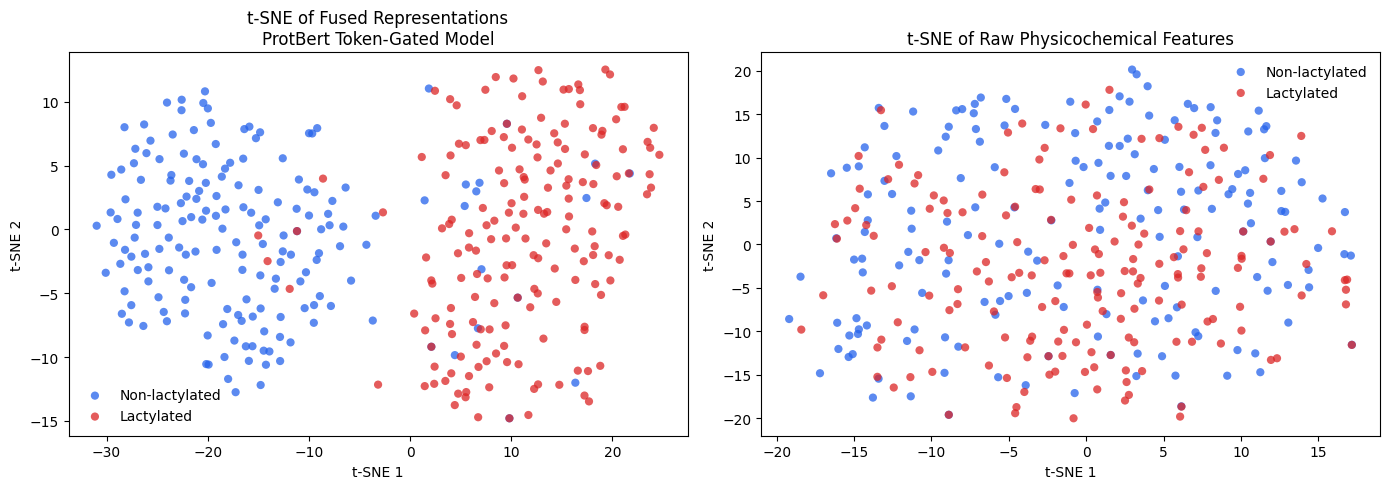

Saved t-SNE figure to: outputs/tsne_fused_vs_physicochemical.png


In [29]:
def run_tsne(features, random_state=42):
    standardized = StandardScaler().fit_transform(features)
    return TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=random_state,
    ).fit_transform(standardized)


def plot_tsne(ax, embedding, labels, title):
    negative = labels == 0
    positive = labels == 1

    ax.scatter(
        embedding[negative, 0],
        embedding[negative, 1],
        s=35,
        alpha=0.75,
        label="Non-lactylated",
        c="#2563EB",
        edgecolors="none",
    )
    ax.scatter(
        embedding[positive, 0],
        embedding[positive, 1],
        s=35,
        alpha=0.75,
        label="Lactylated",
        c="#DC2626",
        edgecolors="none",
    )
    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(frameon=False)


tsne_fused = run_tsne(fused_representations)
tsne_physicochemical = run_tsne(test_split.features)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_tsne(
    axes[0],
    tsne_fused,
    true_labels,
    "t-SNE of Fused Representations\nProtBert Token-Gated Model",
)
plot_tsne(
    axes[1],
    tsne_physicochemical,
    true_labels,
    "t-SNE of Raw Physicochemical Features",
)

plt.tight_layout()
figure_path = PROJECT_DIR / "outputs" / "tsne_fused_vs_physicochemical.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved t-SNE figure to:", figure_path.relative_to(PROJECT_DIR))
